In [1]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import itertools
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
trainset = torchvision.datasets.MNIST('./mnist_data', train = True, download=True, transform=transform)
testset = torchvision.datasets.MNIST('./mnist_data', train=False, download=True, transform=transform)

In [3]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32)
testloader = torch.utils.data.DataLoader(testset, batch_size=32)

In [4]:
class LeNet(nn.Module):

    def __init__(self):
        super().__init__()
        # initial size 1x28x28
        self.conv1 = nn.Conv2d(1,6,5, padding = 2) # 6x28x28
        self.act1 = nn.ReLU()
        self.pool1 = nn.AvgPool2d(2) # 6x14x14
        self.conv2 = nn.Conv2d(6, 16, 5) # 16x10x10
        self.act2 = nn.ReLU()
        self.pool2 = nn.AvgPool2d(2) # 16x5x5 = 400
        self.lin1 = nn.Linear(400, 120)
        self.act3 = nn.ReLU()
        self.lin2 = nn.Linear(120, 84)
        self.act4 = nn.ReLU()
        self.lin3 = nn.Linear(84, 10)
    
    def forward(self, x):
        # x - (batch_size, channel_size, height, width)
        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)
        x = x.flatten(start_dim = 1)
        x = self.lin1(x)
        x = self.act3(x)
        x = self.lin2(x)
        x = self.act4(x)
        x = self.lin3(x)
        return x


In [5]:
model = LeNet()
print(f'Total number of parameters: {sum(p.numel() for p in model.parameters())}')

Total number of parameters: 61706


In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

In [7]:
@torch.no_grad()
def getstats(dataloader, num_batches = 50):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch, labels  in itertools.islice(dataloader, num_batches):
        logits = model(batch)
        loss = F.cross_entropy(logits, labels)
        total_loss += loss.item() * len(batch)
        total += len(batch)
        correct += (logits.argmax(1) == labels).sum().item()
    
    model.train()
    return total_loss / total, correct / total


In [8]:
model.train()
ITERS = len(trainloader)
losses = []
train_accuracy = []
val_accuracy = []
train_losses = []
val_losses = []
checkpoints = []
for iter, (batch, labels) in enumerate(trainloader):
    logits = model(batch)
    loss = F.cross_entropy(logits, labels)
    losses.append(loss.item())
    if iter%100 == 0 or iter == ITERS - 1:
        tr_loss, tr_acc = getstats(trainloader)
        val_loss, val_acc = getstats(testloader)
        print(f'Iteration {iter}/{ITERS - 1}: train loss {tr_loss}, val loss {val_loss}, train accuracy {tr_acc}, val accuracy {val_acc}')
        train_accuracy.append(tr_acc)
        val_accuracy.append(val_acc)
        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        checkpoints.append(iter)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
model.eval();

Iteration 0/1874: train loss 2.3034035301208498, val loss 2.304224519729614, train accuracy 0.095, val accuracy 0.10125
Iteration 100/1874: train loss 0.5213768535852432, val loss 0.5779987663030625, train accuracy 0.840625, val accuracy 0.83125
Iteration 200/1874: train loss 0.46739393800497053, val loss 0.4970539551973343, train accuracy 0.865625, val accuracy 0.84
Iteration 300/1874: train loss 0.28267469331622125, val loss 0.3324069309234619, train accuracy 0.91625, val accuracy 0.889375
Iteration 400/1874: train loss 0.2668146013468504, val loss 0.3028240190446377, train accuracy 0.92125, val accuracy 0.909375
Iteration 500/1874: train loss 0.2410373765975237, val loss 0.26686874888837336, train accuracy 0.9225, val accuracy 0.90375
Iteration 600/1874: train loss 0.17611292224377395, val loss 0.15744481660425663, train accuracy 0.949375, val accuracy 0.950625
Iteration 700/1874: train loss 0.1916857971251011, val loss 0.2048625186085701, train accuracy 0.946875, val accuracy 0.937

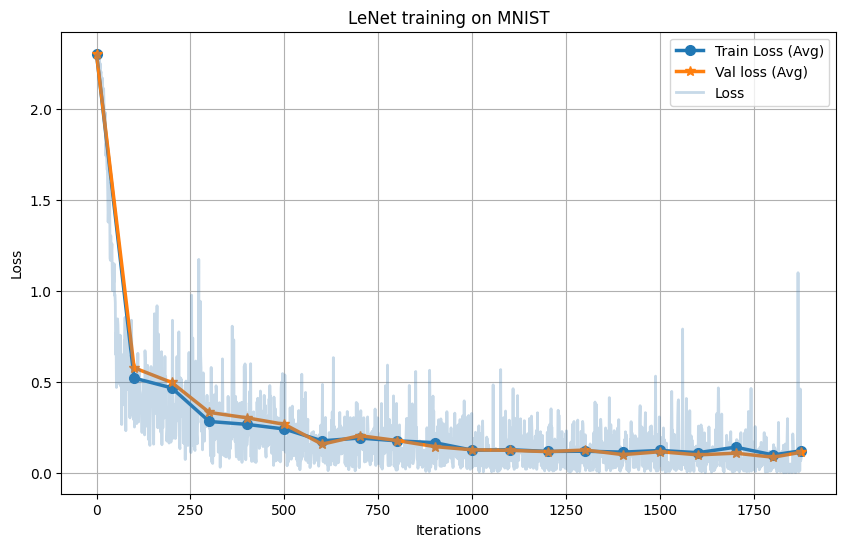

In [26]:
plt.figure(figsize=(10,6))
plt.plot(checkpoints, train_losses, label = 'Train Loss (Avg)', linewidth = 2.5, marker = 'o', markersize = 7)
plt.plot(checkpoints, val_losses, label = 'Val loss (Avg)', linewidth = 2.5, marker = '*', markersize = 7)
plt.plot(losses, label = 'Loss', alpha = 0.3, color = 'steelblue', linewidth = 2)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('LeNet training on MNIST')
plt.legend()
plt.grid()

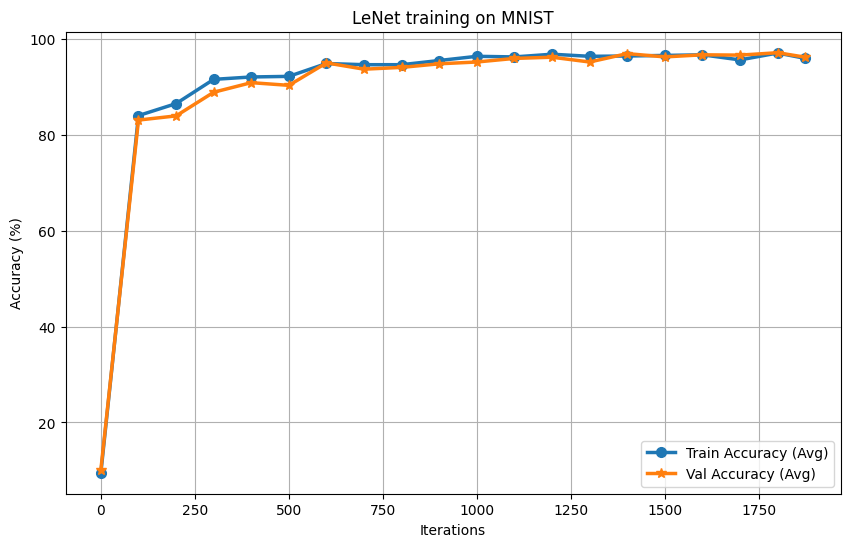

In [27]:
plt.figure(figsize=(10,6))
plt.plot(checkpoints, torch.tensor(train_accuracy)*100, label = 'Train Accuracy (Avg)', linewidth = 2.5, marker = 'o', markersize = 7)
plt.plot(checkpoints, torch.tensor(val_accuracy) *100, label = 'Val Accuracy (Avg)', linewidth = 2.5, marker = '*', markersize = 7)
plt.xlabel('Iterations')
plt.ylabel('Accuracy (%)')
plt.title('LeNet training on MNIST')
plt.legend()
plt.grid()

In [30]:
final_train_loss, final_train_accuracy = getstats(trainloader, len(trainloader))
final_val_loss, final_val_accuracy = getstats(testloader, len(testloader))
print('FINAL STATS')
print('-' * 50)
print(f'Train Loss: {final_train_loss}, Train Accuracy: {final_train_accuracy * 100}%')
print(f'Val Loss: {final_val_loss}, Val Accuracy: {final_val_accuracy*100}%')

FINAL STATS
--------------------------------------------------
Train Loss: 0.10104313022289425, Train Accuracy: 96.90666666666667%
Val Loss: 0.08912151785753668, Val Accuracy: 97.17%
